## Embeddings et similarité sémantique

In [1]:
# Installation
# !uv add sentence-transformers numpy matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Chargement du modèle

In [3]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print(f"Dimensions : {model.get_embedding_dimension()}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11870.05it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimensions : 384


2. Création d'embeddings

In [4]:
text = "Le machine learning permet aux ordinateurs d'apprendre."
embedding = model.encode(text)

print(f"Texte : {text}")
print(f"Shape : {embedding.shape}")
print(f"Premières valeurs : {embedding[:5]}")

Texte : Le machine learning permet aux ordinateurs d'apprendre.
Shape : (384,)
Premières valeurs : [ 0.01536176 -0.01973782 -0.07249069 -0.15339422 -0.06792685]


In [5]:
texts = [
    "Le chat dort sur le canapé",
    "Le félin sommeille sur le sofa",
    "JavaScript est un langage de programmation",
    "La voiture roule sur l'autoroute",
    "L'animal se repose sur le meuble",
]

embeddings = model.encode(texts)
print(f"Shape : {embeddings.shape}")

Shape : (5, 384)


In [6]:
def manual_cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


similarity = manual_cosine_similarity(embeddings[0], embeddings[1])
print(f"Similarité {texts[0]} vs {texts[1]} : {similarity}")

Similarité Le chat dort sur le canapé vs Le félin sommeille sur le sofa : 0.5828378796577454


In [7]:
similarity = manual_cosine_similarity(embeddings[0], embeddings[2])
print(f"Similarité {texts[0]} vs {texts[2]} : {similarity}")

Similarité Le chat dort sur le canapé vs JavaScript est un langage de programmation : -0.04786859452724457


In [8]:
similarity_matrix = cosine_similarity(embeddings)
print(np.round(similarity_matrix, 2))

[[ 1.    0.58 -0.05 -0.02  0.45]
 [ 0.58  1.   -0.01  0.1   0.47]
 [-0.05 -0.01  1.   -0.07  0.05]
 [-0.02  0.1  -0.07  1.   -0.03]
 [ 0.45  0.47  0.05 -0.03  1.  ]]


4. Visualisation Heatmap

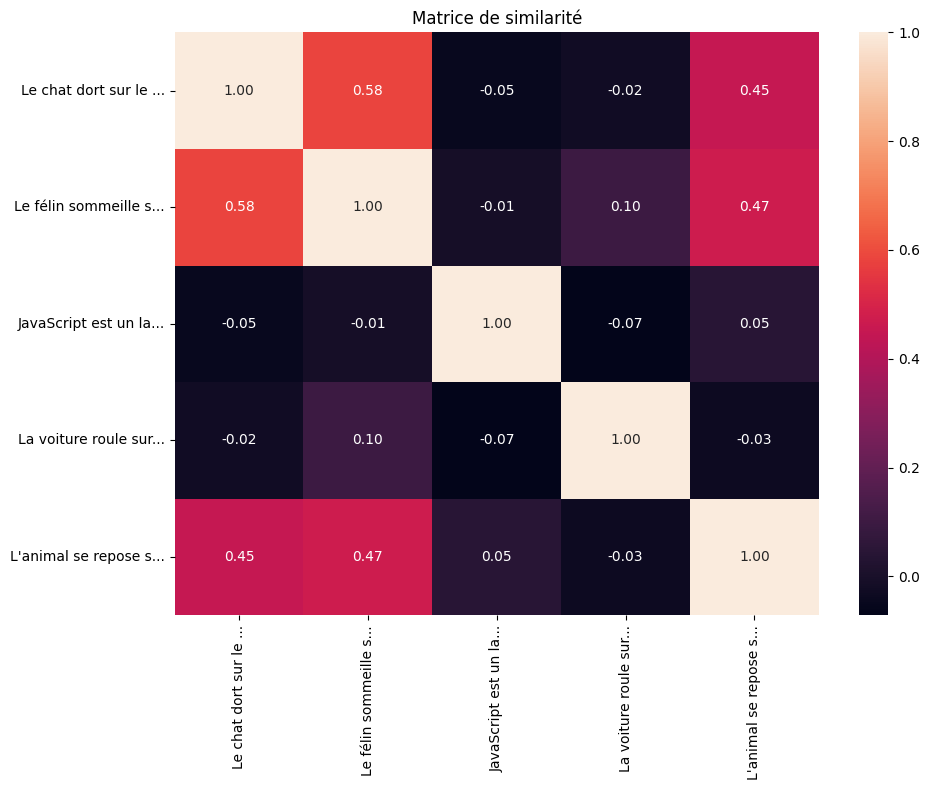

In [ ]:
plt.figure(figsize=(10, 8))
labels = [t[:20] + "..." for t in texts]

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt="0.2f",
    xticklabels=labels,
    yticklabels=labels,
)

plt.title("Matrice de similarité")
plt.tight_layout()
plt.show()

5. Recherche sémantique

In [10]:
all_texts = [
    "Le chat dort",
    "Le chien joue",
    "L'oiseau chante",
    "Python code",
    "JavaScript web",
    "Java entreprise",
    "Chef cuisine",
    "Recette œufs",
    "Restaurant végétarien",
    "Physique quantique",
    "ADN génétique",
    "Étoiles univers",
]


def semantic_search(query, documents, model, top_k=3):
    query_emb = model.encode([query])
    docs_emb = model.encode(documents)
    similarities = cosine_similarity(query_emb, docs_emb)[0]
    ranked = np.argsort(similarities)[::-1][:top_k]
    return [(documents[i], similarities[i]) for i in ranked]


results = semantic_search("Comment les animaux se comportent ?", all_texts, model)

for doc, score in results:
    print(f"{score} - {doc}")

0.5514671206474304 - Le chien joue
0.26026400923728943 - Étoiles univers
0.24352405965328217 - L'oiseau chante
